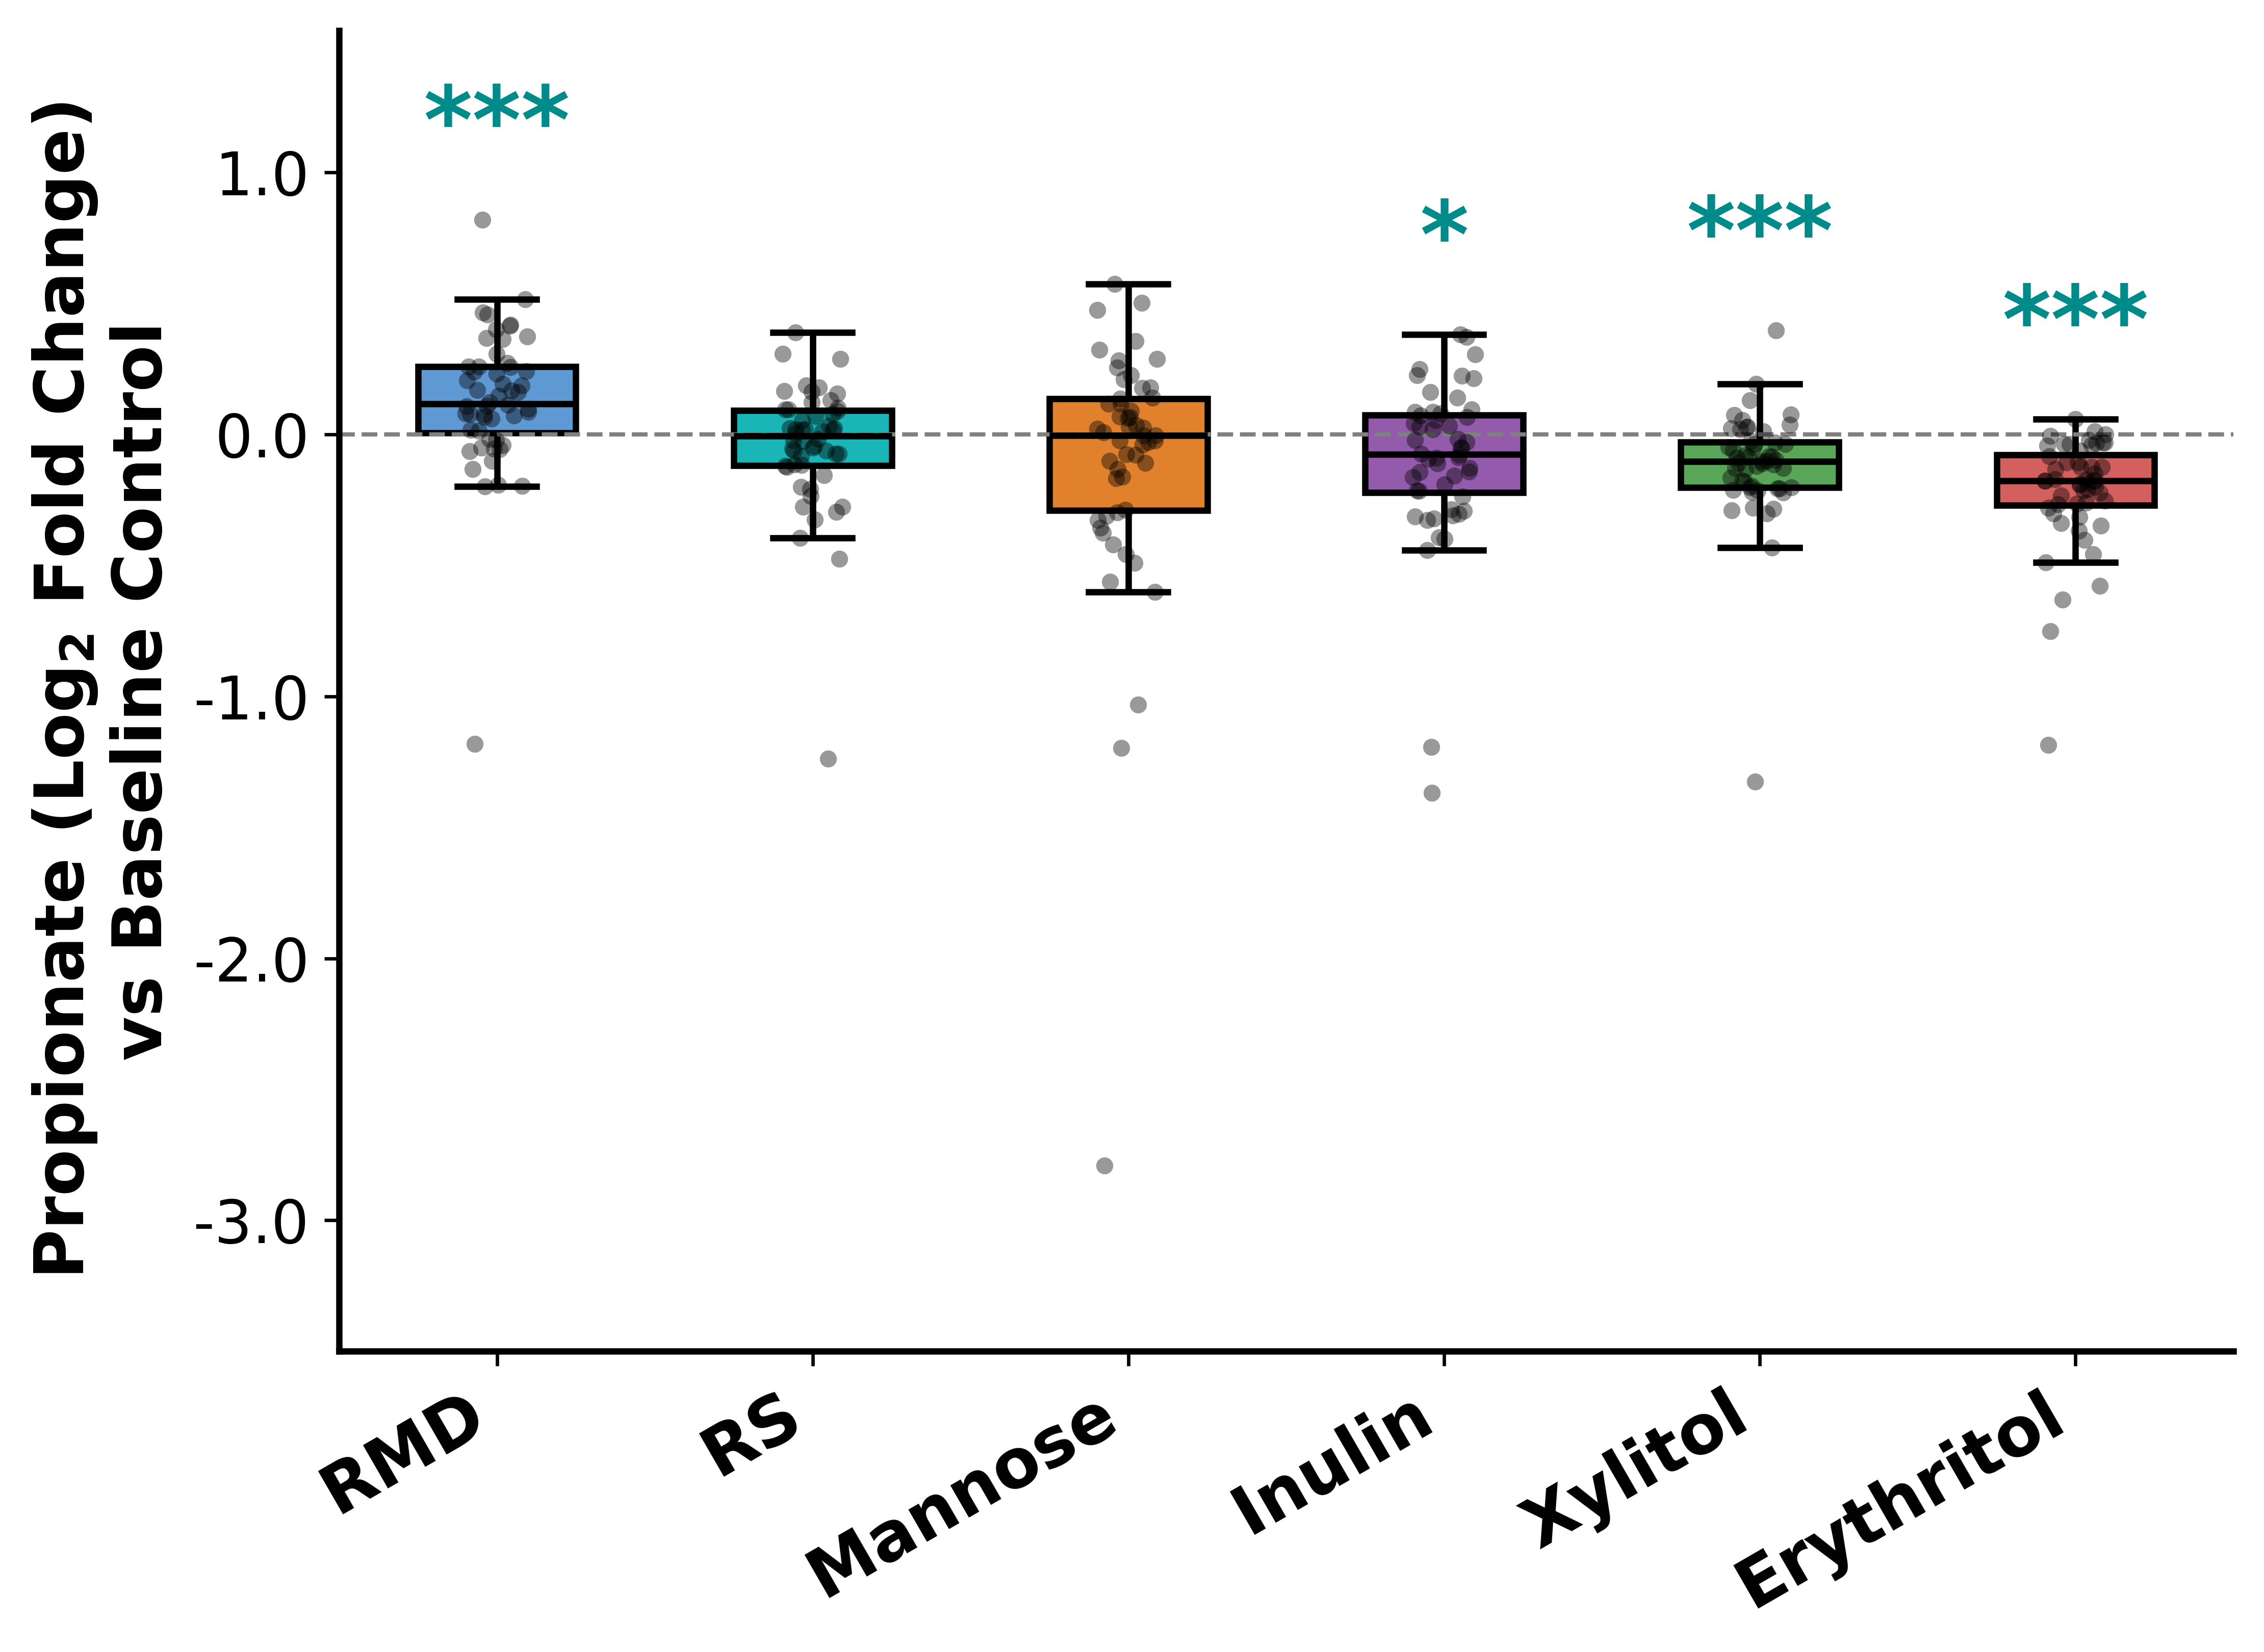

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.multitest as multitest
import warnings

warnings.filterwarnings('ignore')

# 1. Global Page and Font Settings
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

# Color palette (Unified for S3)
strong_palette = {
    'RMD': '#4C99E6', 'RS': '#00CED1', 'Mannose': '#ff7f0e',
    'Inulin': '#9A4CBA', 'Xylitol': '#4CB34C', 'Erythritol': '#E64C4C'
}

target_ingredients = ['Resistant maltodextrin', 'Resistant starch', 'Mannose', 'Inulin', 'Xylitol', 'Erythritol']
name_map = {'Resistant maltodextrin': 'RMD', 'Resistant starch': 'RS', 'Mannose': 'Mannose',
            'Inulin': 'Inulin', 'Xylitol': 'Xylitol', 'Erythritol': 'Erythritol'}
order = ['RMD', 'RS', 'Mannose', 'Inulin', 'Xylitol', 'Erythritol']

def get_star(q):
    if q < 0.001: return '***'
    elif q < 0.01: return '**'
    elif q < 0.05: return '*'
    else: return ''

def clean_and_convert_strict(vals):
    s_vals = pd.Series(vals).astype(str).replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s_vals, errors='coerce')

# 2. Data Loading (Propionate)
df = pd.read_csv('Propionate(mM).csv')
donor_cols = [c for c in df.columns if c.startswith('HS-')]

ctrl_mask = df.iloc[:, 2].astype(str).str.contains('Control', case=False, na=False)
if not ctrl_mask.any(): ctrl_mask = df.iloc[:, 0].astype(str).isin(['0', '000'])
ctrl_vals = clean_and_convert_strict(df.loc[ctrl_mask, donor_cols].iloc[0].values)

plot_data, p_values, targets = [], [], []

for ingredient in target_ingredients:
    mask = df.iloc[:, 2] == ingredient
    if not mask.any() and ingredient == 'Mannose':
        mask = df.iloc[:, 2].str.contains('Mannose', case=False, na=False)
    if not mask.any(): continue

    treat_vals = clean_and_convert_strict(df.loc[mask, donor_cols].iloc[0].values)
    pair_df = pd.DataFrame({'Ctrl': ctrl_vals, 'Treat': treat_vals}).dropna()
    if len(pair_df) == 0: continue

    pseudo = 0.01
    log2fc_vals = np.log2((pair_df['Treat'] + pseudo) / (pair_df['Ctrl'] + pseudo))
    delta = pair_df['Treat'] - pair_df['Ctrl']

    if np.all(delta.values == 0): p = 1.0
    else:
        try: _, p = stats.wilcoxon(pair_df['Treat'], pair_df['Ctrl'], zero_method='wilcox')
        except ValueError: p = 1.0

    p_values.append(p)
    targets.append(name_map[ingredient])
    for v in log2fc_vals: plot_data.append({'Ingredient': name_map[ingredient], 'Log2FC': v})

_, q_vals, _, _ = multitest.multipletests(p_values, alpha=0.05, method='fdr_bh')
q_dict = dict(zip(targets, q_vals))
df_fig = pd.DataFrame(plot_data)

# 3. Figure Generation
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=DPI_SETTING)
sns.boxplot(x='Ingredient', y='Log2FC', data=df_fig, order=order, palette=strong_palette, width=0.5, showfliers=False, ax=ax, linewidth=1.5)

for patch in ax.patches: patch.set_edgecolor('black')
for line in ax.lines: line.set_color('black')

sns.stripplot(x='Ingredient', y='Log2FC', data=df_fig, order=order, color='black', alpha=0.4, size=4, jitter=True, ax=ax)
ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_ylabel(r'Propionate (Log$_{\mathbf{2}}$ Fold Change)' + '\n' + 'vs Baseline Control', fontsize=16, fontweight='bold')
ax.set_xlabel('')

for s in ['top', 'right']: ax.spines[s].set_visible(False)
for s in ['left', 'bottom']: ax.spines[s].set_linewidth(1.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=16, fontweight='bold')

y_max, y_min = df_fig['Log2FC'].max(), df_fig['Log2FC'].min()
y_range = y_max - y_min
ax.set_ylim(bottom=np.floor(y_min) - 0.5, top=np.ceil(y_max) + y_range * 0.15)
yticks = ax.get_yticks()
ax.set_yticklabels([f"{y:.1f}" for y in yticks], fontsize=14, fontweight='normal')

for i, name in enumerate(order):
    if name in q_dict and q_dict[name] < 0.05:
        g_max = df_fig[df_fig['Ingredient'] == name]['Log2FC'].max()
        ax.text(i, g_max + y_range * 0.05, get_star(q_dict[name]), ha='center', va='bottom', fontsize=22, fontweight='bold', color='#008B8B')

plt.tight_layout()
plt.savefig("Supplementary_Figure_S3a.pdf", dpi=DPI_SETTING, format='pdf', bbox_inches='tight', transparent=True)